## Preperation

In [1]:
import os
from tqdm import tqdm
import torch
import random
import numpy as np
import torch.nn as nn
from Model import EEGModel
from Data import EEGDataLoader
from Evaluation import visualizer
from Evaluation import ExperimentDataSaver

In [2]:
DATA_PATH = '.\\RawDataset\\'
CACHE_PATH = '.\\Dataset\\'
MODEL_PATH = '.\\Models\\'
data_saver = ExperimentDataSaver(root_path='.\\Results\\')

CRITERION = nn.CrossEntropyLoss()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ARCHITECTURES = ['DeepConvNet', 'ShallowFBCSPNet', 'CTNet', 'Deep4Net']

SUBJECT_COUNT = 15
LEARNING_RATE = 0.005
P_LEARNING_RATE = 0.01
BATCH_SIZE = 8
P_BATCH_SIZE = 16
LOG_INTERVAL = 5
MAX_EPOCH = 50
PATIENCE = 7
RANDOM_SEED = 42
SPLIT = (0.7, 0.1, 0.2)

In [3]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

## DataLoading

Target Classes: ['Elbow Flexion', 'Elbow Extension', 'Supination', 'Pronation', 'Hand Open', 'Hand Close', 'Rest']


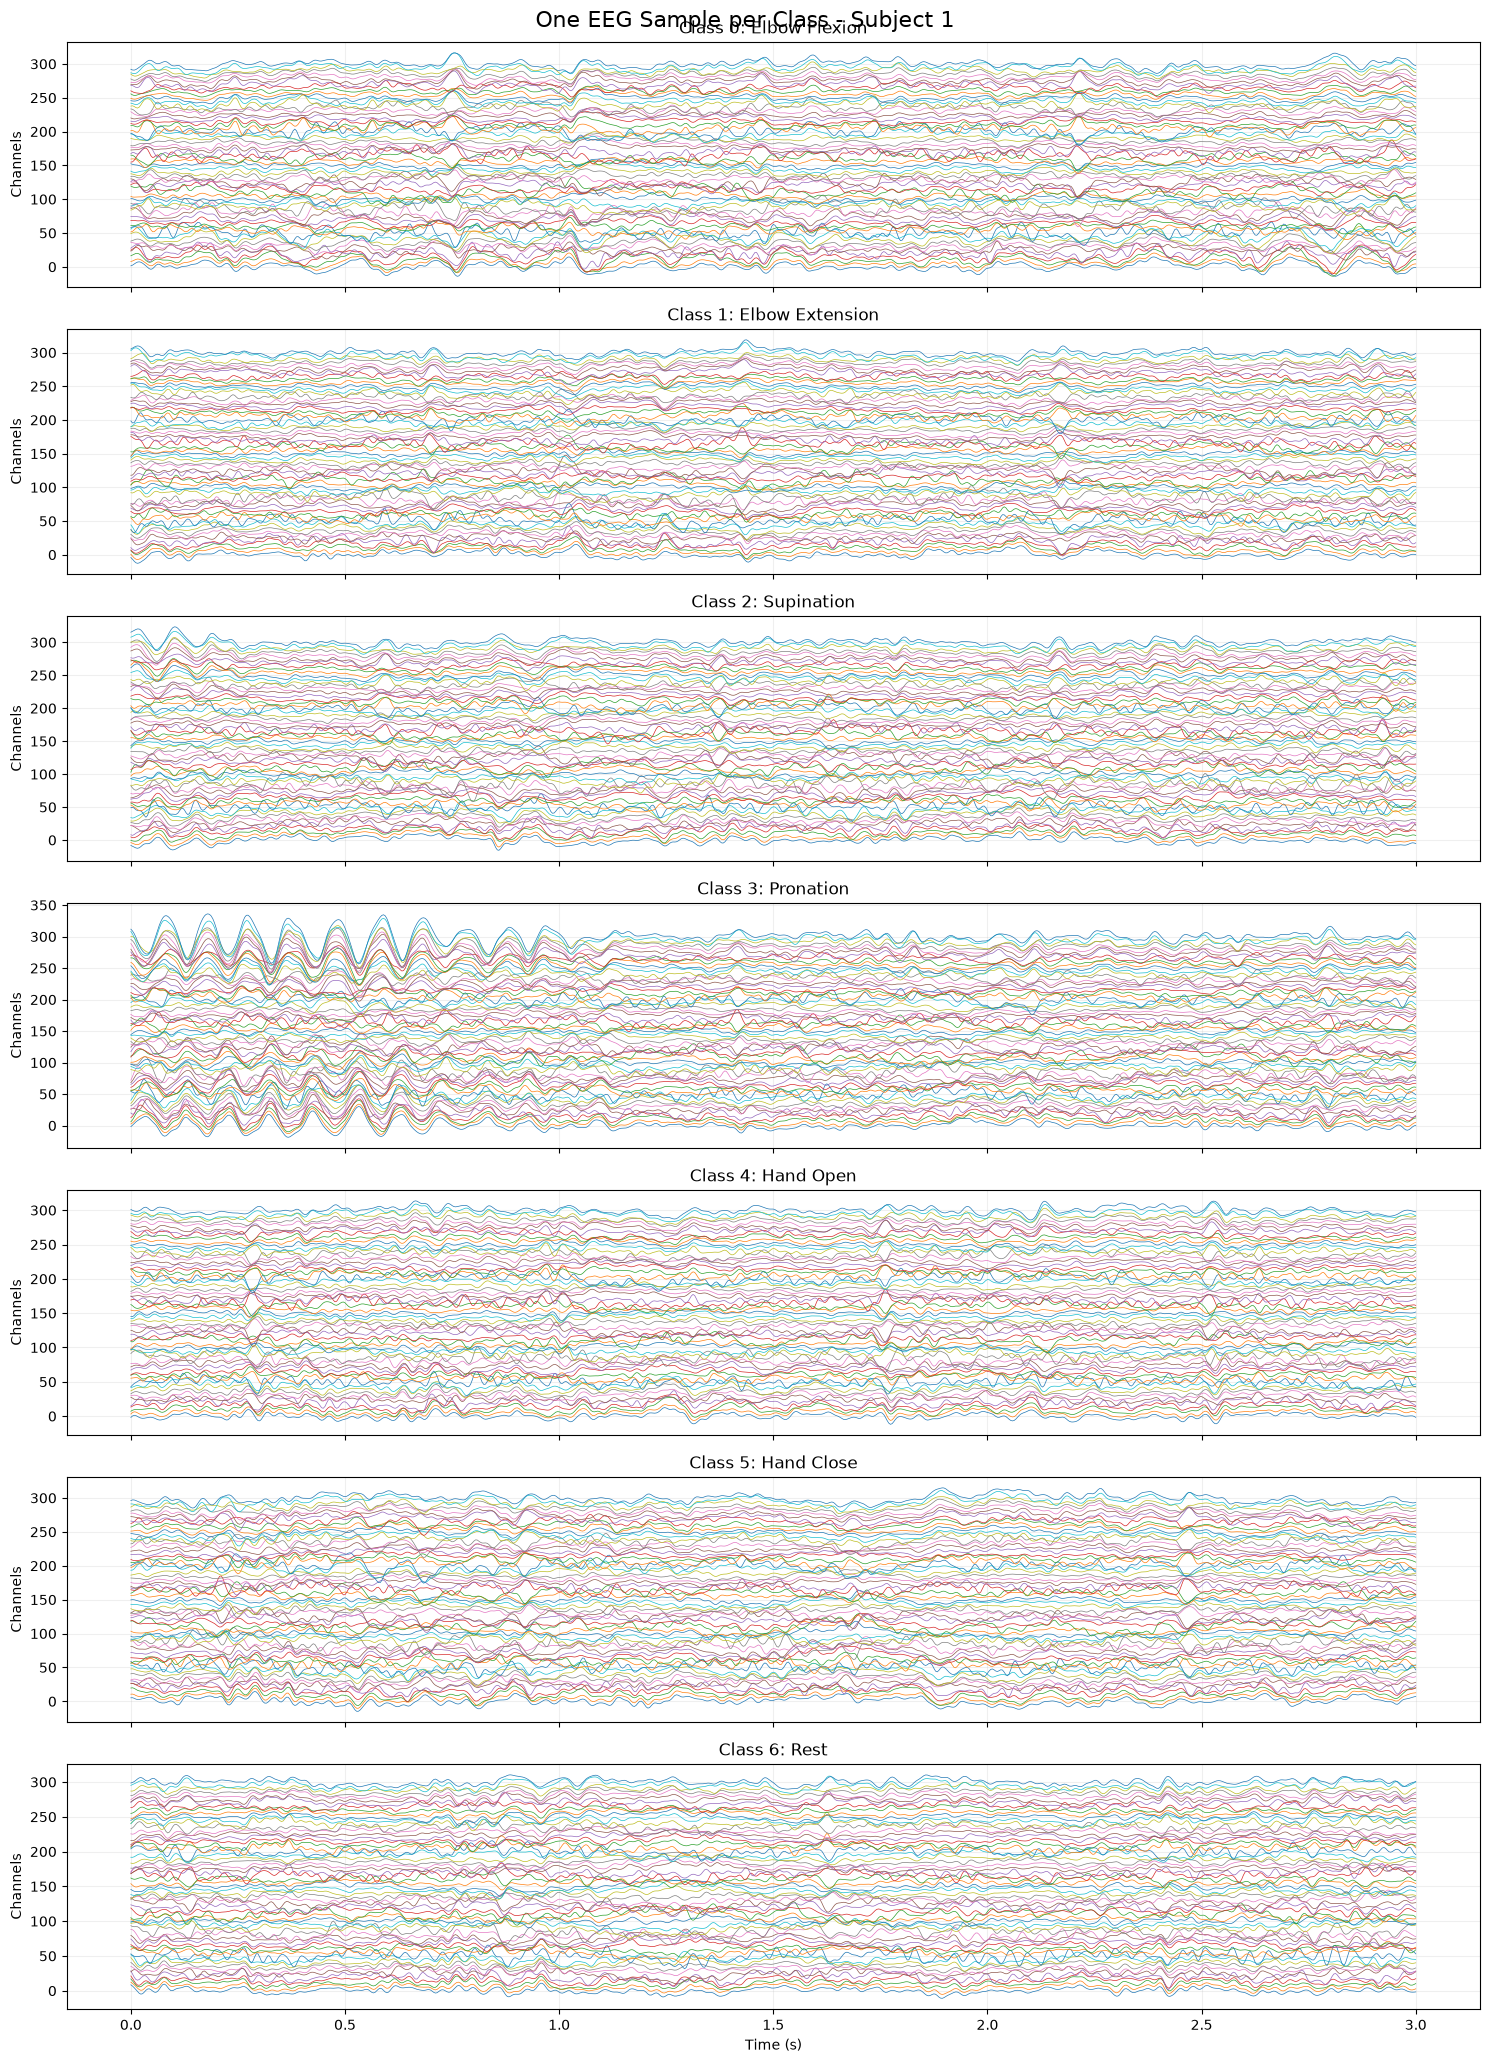

In [4]:
data_loader_factory = EEGDataLoader(
    data_path=DATA_PATH, 
    cache_path=CACHE_PATH, 
    batch_size=BATCH_SIZE,
    split_ratios=SPLIT
)

classes = data_loader_factory.get_class_names()
print(f"Target Classes: {classes}")
visualizer.visualize_one_sample_per_label(
    data_loader_factory,
    subject=1
)

## Models and Architectures 

In [5]:
for architecture in MODEL_ARCHITECTURES:
    print('#' * 25, architecture, '#' * 25)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    print('#' * 65)

######################### DeepConvNet #########################
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100

## Base-Line

### Solid Training 

#################### Selected Architecture: DeepConvNet ####################
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Subject #1:	Train Acc: 92.57	Test Acc: 48.39	Validation Acc: 58.70
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Subject #2:	Train Acc: 95.36	Test Acc: 44.09	Validation Acc: 47.83
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Subject #3:	Train Acc: 97.52	Test Acc: 93.55	Validation Acc: 91.30
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Subject #4:	Train Acc: 86.69	Test Acc: 80.65	Validation Acc: 84.78
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Subject #5:	Train Acc: 69.04	Test Acc: 32.26	Validation Acc: 36.96
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Subject #6:	Train Acc: 85.14	Test Acc: 47.31	Validation Acc: 52.17
Loading Sub

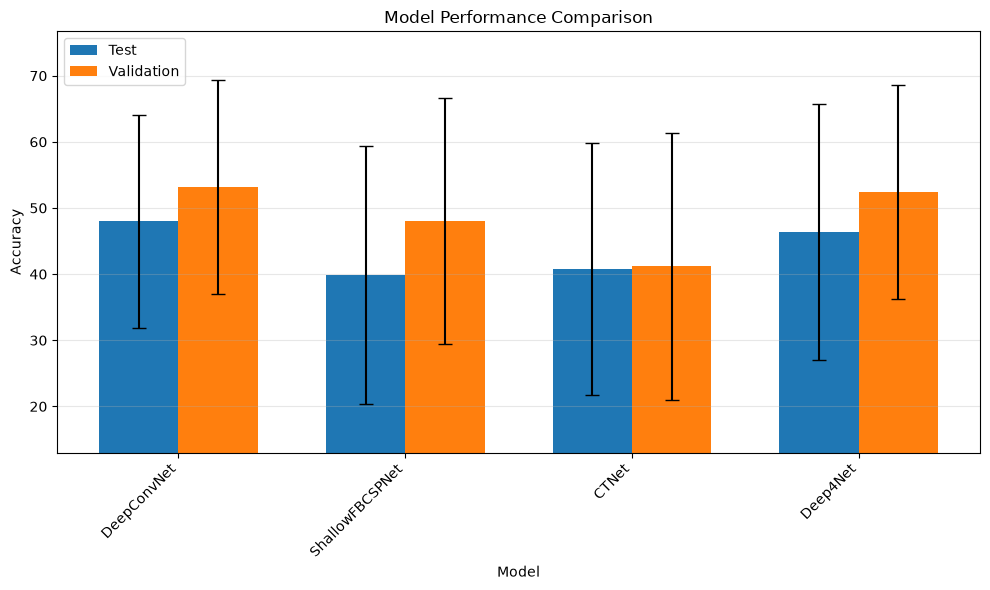

In [6]:
test_mean, test_var, val_mean, val_var = [], [], [], []
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    test_accs, val_accs = [], []
    for subject_id in range(1, 1 + SUBJECT_COUNT):
        train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        model_path = str(MODEL_PATH + f'Subject {subject_id}\\{architecture}_{LEARNING_RATE}.pth')
        model.fit(
            train_loader=train_loader,
            val_loader=val_loader,
            max_epochs=MAX_EPOCH,
            patience=PATIENCE,
            save_path=model_path,
            verbose=False
        )

        test_acc = model.evaluate_accuracy(test_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        train_acc = model.evaluate_accuracy(train_loader)
        test_accs.append(test_acc)
        val_accs.append(val_acc)
        print(f'Subject #{subject_id}:\tTrain Acc: {train_acc:.2f}\tTest Acc: {test_acc:.2f}\tValidation Acc: {val_acc:.2f}')

        data_saver.set_data(architecture, 'Train', 'avg', subject_id, train_acc)
        data_saver.set_data(architecture, 'Train', 'std', subject_id, None)
        data_saver.set_data(architecture, 'Validation', 'avg', subject_id, val_acc)
        data_saver.set_data(architecture, 'Validation', 'std', subject_id, None)
        data_saver.set_data(architecture, 'Test', 'avg', subject_id, test_acc)
        data_saver.set_data(architecture, 'Test', 'std', subject_id, None)

    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n\n')

data_saver.save_excel("Results.xlsx")

visualizer.plot_model_performance(
    MODEL_ARCHITECTURES,
    test_means=test_mean,
    test_vars=test_var,
    val_means=val_mean,
    val_vars=val_var
)

### K-Fold Training

Selected Architecture: DeepConvNet

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
  Fold 1:	Train Acc: 88.08	Val Acc: 45.16
  Fold 2:	Train Acc: 81.03	Val Acc: 43.01
  Fold 3:	Train Acc: 84.05	Val Acc: 50.00
  Fold 4:	Train Acc: 68.38	Val Acc: 43.48
  Fold 5:	Train Acc: 85.68	Val Acc: 53.26

Model Accuracy (Averaged over Folds) Validation: ~N(46.982, 15.979)


============= Evaluating Subject #2 =============
Loading Subject 2 from cache...

==================== Fold 1/5 ===

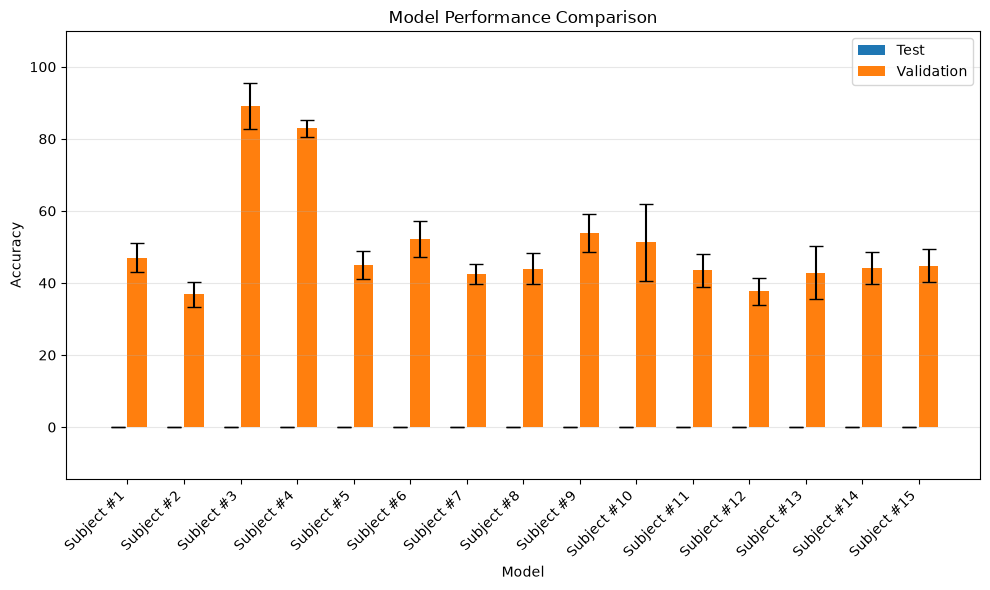

Selected Architecture: ShallowFBCSPNet

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
  Fold 1:	Train Acc: 65.31	Val Acc: 30.11
  Fold 2:	Train Acc: 60.98	Val Acc: 30.11
  Fold 3:	Train Acc: 92.70	Val Acc: 43.48
  Fold 4:	Train Acc: 86.76	Val Acc: 40.22
  Fold 5:	Train Acc: 97.57	Val Acc: 48.91

Model Accuracy (Averaged over Folds) Validation: ~N(38.565, 55.402)


============= Evaluating Subject #2 =============
Loading Subject 2 from cache...

==================== Fold 1/5

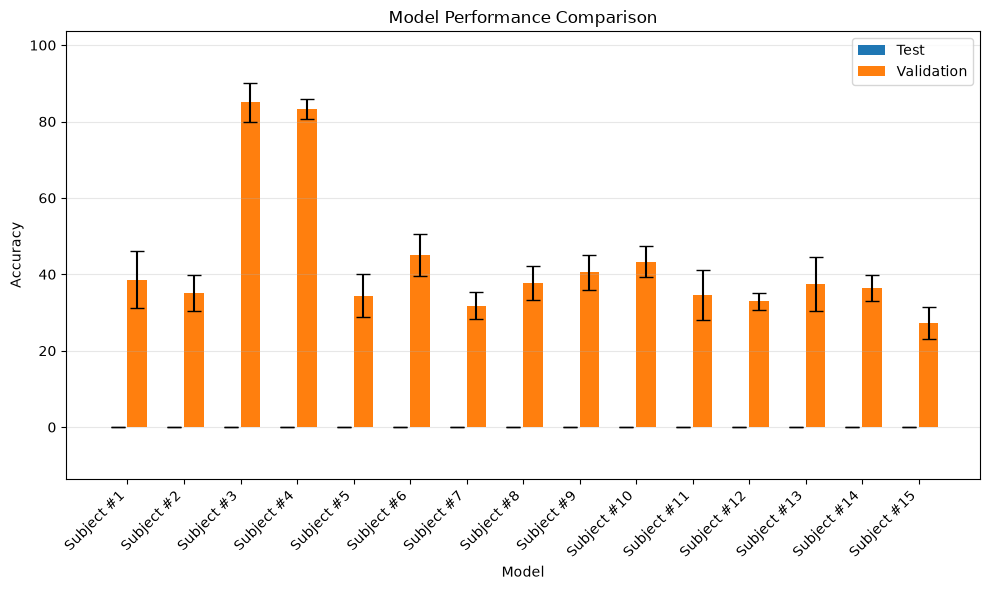

Selected Architecture: CTNet

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
  Fold 1:	Train Acc: 57.99	Val Acc: 34.41
  Fold 2:	Train Acc: 84.55	Val Acc: 39.78
  Fold 3:	Train Acc: 62.70	Val Acc: 19.57
  Fold 4:	Train Acc: 60.27	Val Acc: 26.09
  Fold 5:	Train Acc: 90.54	Val Acc: 42.39

Model Accuracy (Averaged over Folds) Validation: ~N(32.447, 72.595)


============= Evaluating Subject #2 =============
Loading Subject 2 from cache...

==================== Fold 1/5 =========

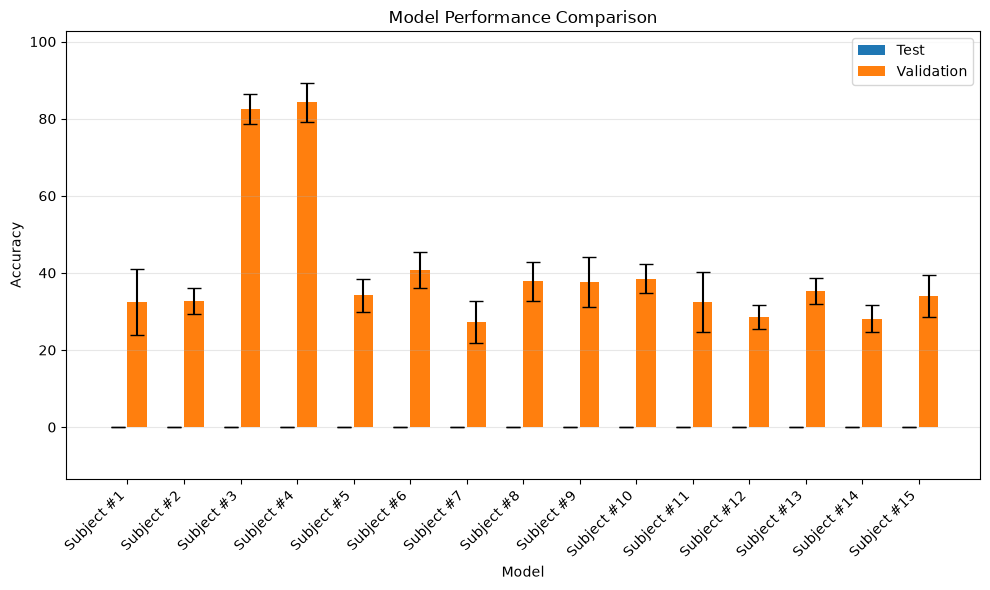

Selected Architecture: Deep4Net

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
  Fold 1:	Train Acc: 94.31	Val Acc: 60.22
  Fold 2:	Train Acc: 83.47	Val Acc: 52.69
  Fold 3:	Train Acc: 83.24	Val Acc: 55.43
  Fold 4:	Train Acc: 80.27	Val Acc: 50.00
  Fold 5:	Train Acc: 85.41	Val Acc: 53.26

Model Accuracy (Averaged over Folds) Validation: ~N(54.320, 11.688)


============= Evaluating Subject #2 =============
Loading Subject 2 from cache...

==================== Fold 1/5 ======

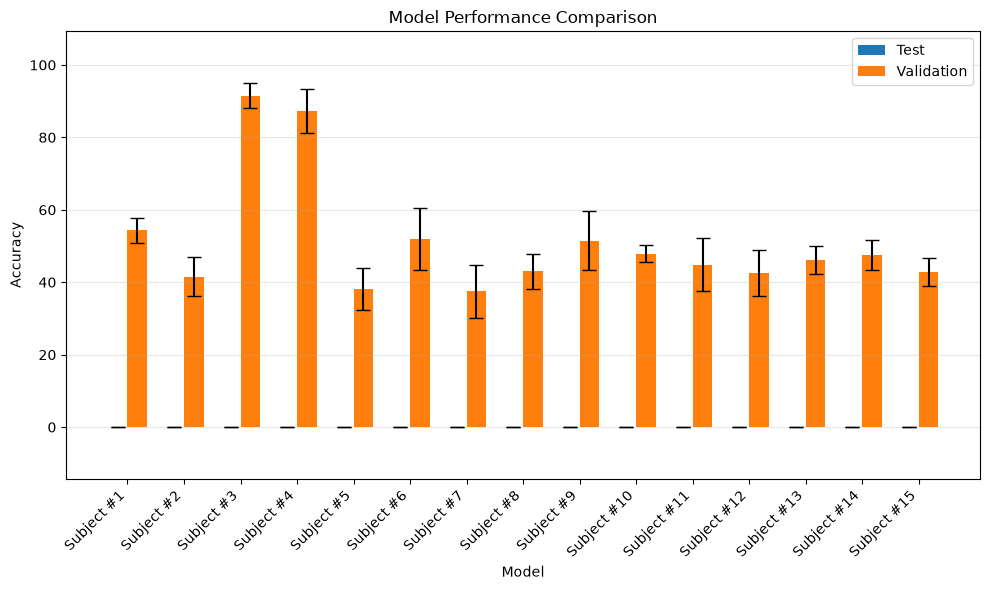

In [7]:
for architecture in MODEL_ARCHITECTURES:
    val_mean, val_var = [], []
    k_folds = 5
    print(f'Selected Architecture: {architecture}')

    for subject_id in range(1, 1 + SUBJECT_COUNT):
        print(f'\n============= Evaluating Subject #{subject_id} =============')
        fold_loaders = data_loader_factory.get_k_fold_dataloaders(
            subject=subject_id, 
            k=k_folds, 
            random_seed=RANDOM_SEED
        )
        val_accs = []
        train_accs = []

        for fold_idx, (train_loader, val_loader) in enumerate(fold_loaders):
            model = EEGModel(
                criterion=CRITERION,
                learning_rate=LEARNING_RATE,
                architecture_key=architecture,
                random_seed=RANDOM_SEED,
                device=DEVICE
            )
            model_path = str(MODEL_PATH + f'Subject {subject_id}\\Fold_{fold_idx+1}_{architecture}_{LEARNING_RATE}.pth')
            
            model.fit(
                train_loader=train_loader,
                val_loader=val_loader,
                max_epochs=MAX_EPOCH,
                patience=PATIENCE,
                save_path=model_path,
                verbose=False
            )
            
            final_val_acc = model.evaluate_accuracy(val_loader)
            final_train_acc = model.evaluate_accuracy(train_loader)
            
            val_accs.append(final_val_acc)
            train_accs.append(final_train_acc)
            print(f'  Fold {fold_idx + 1}:\tTrain Acc: {final_train_acc:.2f}\tVal Acc: {final_val_acc:.2f}')
        
        val_mean.append(np.mean(val_accs))
        val_var.append(np.var(val_accs))

        print(f'\nModel Accuracy (Averaged over Folds) Validation: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')
        t_avg, t_std = np.mean(train_accs), np.std(train_accs)
        v_avg, v_std = np.mean(val_accs), np.std(val_accs)
        
        data_saver.set_data(architecture, 'Train', 'avg', subject_id, t_avg)
        data_saver.set_data(architecture, 'Train', 'std', subject_id, t_std)
        data_saver.set_data(architecture, 'Validation', 'avg', subject_id, v_avg)
        data_saver.set_data(architecture, 'Validation', 'std', subject_id, v_std)
        data_saver.set_data(architecture, 'Test', 'avg', subject_id, None)
        data_saver.set_data(architecture, 'Test', 'std', subject_id, None)

    data_saver.save_excel("Results.xlsx")

    visualizer.plot_model_performance(
        [f'Subject #{i + 1}' for i in range(SUBJECT_COUNT)],
        test_means=[0 for i in range(SUBJECT_COUNT)],
        test_vars=[0 for i in range(SUBJECT_COUNT)],
        val_means=val_mean,
        val_vars=val_var
    )

## Pretraining


-------- Setting up training for ALL Subjects --------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading

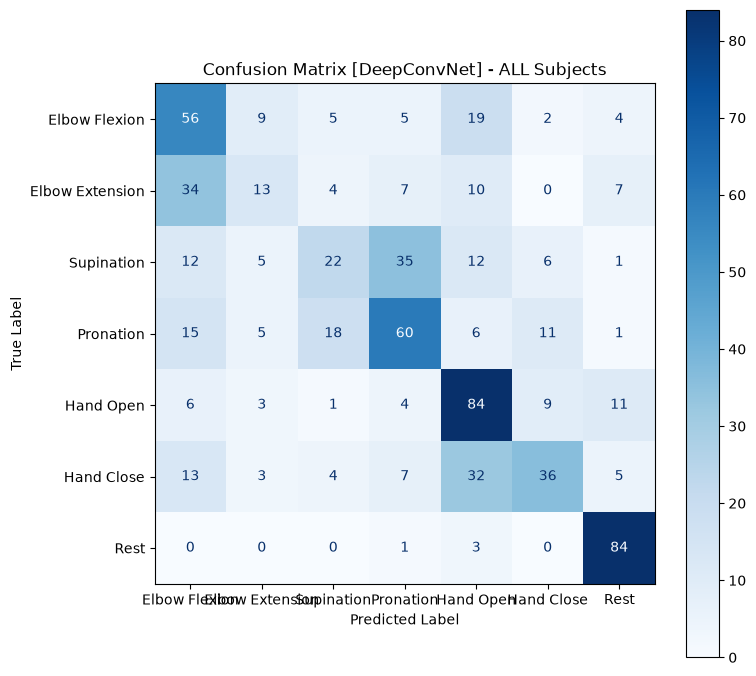

Selected Architecture: ShallowFBCSPNet
Epoch [1/50] | Train Loss: 4.1299 | Val Loss: 3.7688
Model saved successfully to .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth
Epoch [2/50] | Train Loss: 3.3438 | Val Loss: 2.0344
Model saved successfully to .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth
Epoch [3/50] | Train Loss: 2.1795 | Val Loss: 1.6449
Model saved successfully to .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth
Epoch [4/50] | Train Loss: 1.6945 | Val Loss: 1.6158
Model saved successfully to .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth
Epoch [5/50] | Train Loss: 1.5890 | Val Loss: 1.4985
Model saved successfully to .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth
Epoch [6/50] | Train Loss: 1.5129 | Val Loss: 1.5248
Epoch [7/50] | Train Loss: 1.4877 | Val Loss: 1.4809
Model saved successfully to .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth
Epoch [8/50] | Train Loss: 1.4956 | Val Loss: 1.46

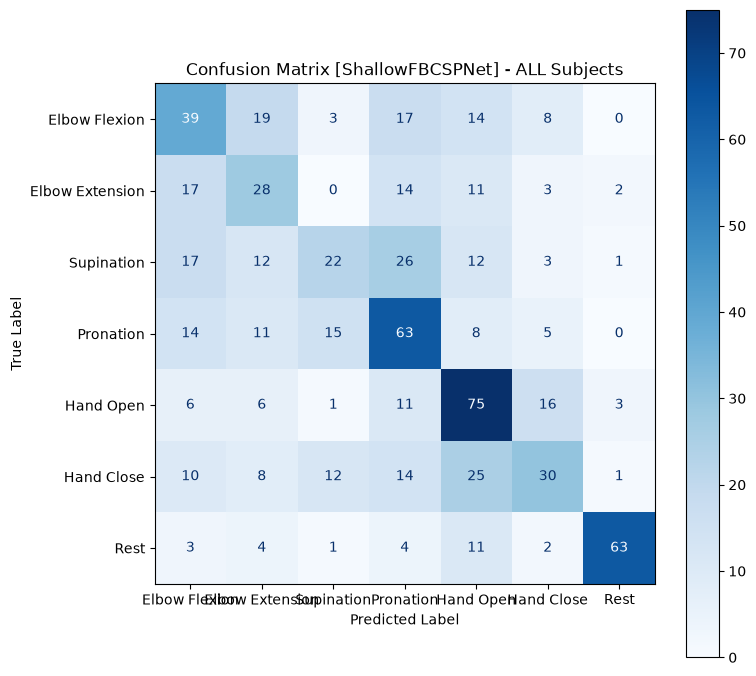

Selected Architecture: CTNet
Epoch [1/50] | Train Loss: 2.0308 | Val Loss: 1.6497
Model saved successfully to .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth
Epoch [2/50] | Train Loss: 1.6223 | Val Loss: 1.5645
Model saved successfully to .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth
Epoch [3/50] | Train Loss: 1.5172 | Val Loss: 1.5582
Model saved successfully to .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth
Epoch [4/50] | Train Loss: 1.4495 | Val Loss: 1.5113
Model saved successfully to .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth
Epoch [5/50] | Train Loss: 1.4007 | Val Loss: 1.4525
Model saved successfully to .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth
Epoch [6/50] | Train Loss: 1.3475 | Val Loss: 1.5698
Epoch [7/50] | Train Loss: 1.2965 | Val Loss: 1.4567
Epoch [8/50] | Train Loss: 1.2555 | Val Loss: 1.3837
Model saved successfully to .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth
Epoch [9/50] | Train Loss: 1.2023 | Val Loss: 1.5433
Epoch [10/50] 

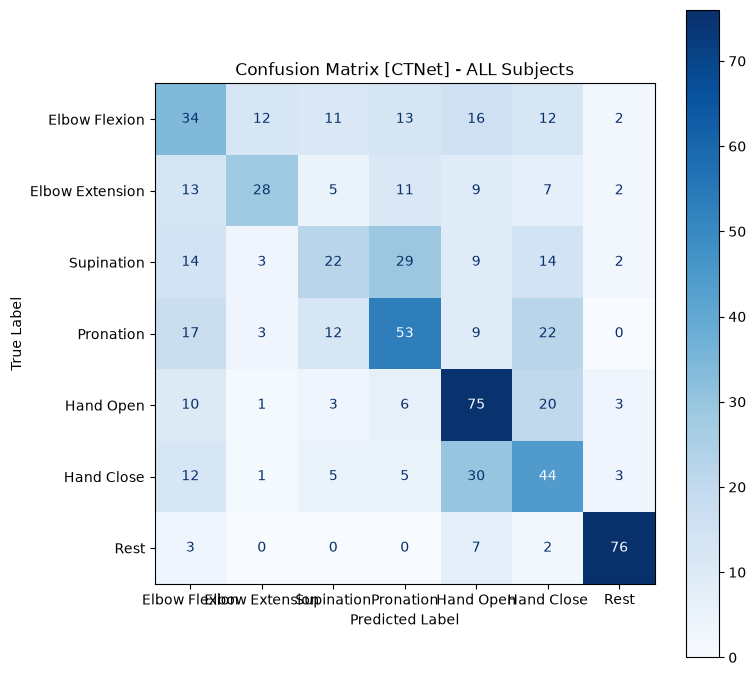

Selected Architecture: Deep4Net
Epoch [1/50] | Train Loss: 2.0299 | Val Loss: 1.8977
Model saved successfully to .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth
Epoch [2/50] | Train Loss: 1.8125 | Val Loss: 1.7251
Model saved successfully to .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth
Epoch [3/50] | Train Loss: 1.7046 | Val Loss: 1.6001
Model saved successfully to .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth
Epoch [4/50] | Train Loss: 1.6318 | Val Loss: 1.6749
Epoch [5/50] | Train Loss: 1.6137 | Val Loss: 1.5955
Model saved successfully to .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth
Epoch [6/50] | Train Loss: 1.5842 | Val Loss: 1.5191
Model saved successfully to .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth
Epoch [7/50] | Train Loss: 1.5667 | Val Loss: 1.4809
Model saved successfully to .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth
Epoch [8/50] | Train Loss: 1.5367 | Val Loss: 1.4816
Epoch [9/50] | Train Loss: 1.5210 | Val Loss: 

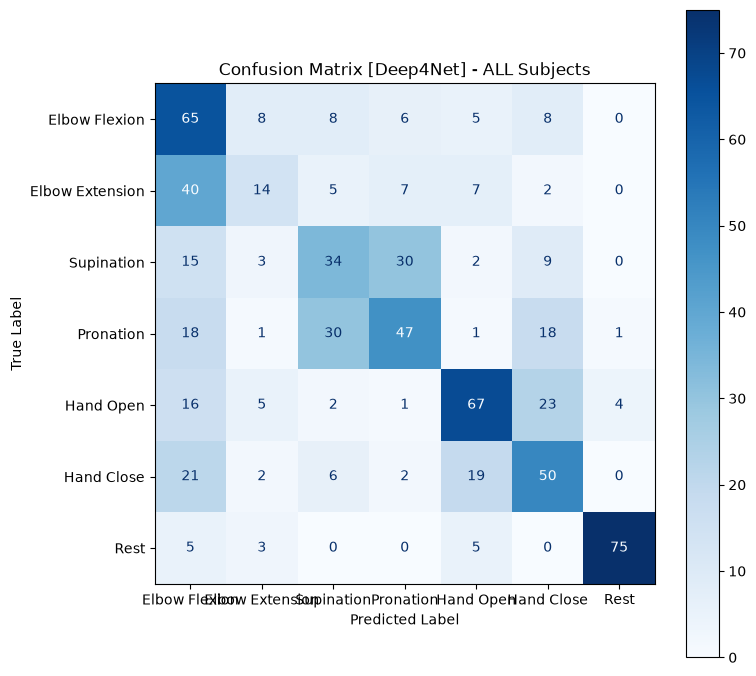

Finished training.

-------- Setting up training for ALL Subjects Except 1--------


ValueError: list.remove(x): x not in list

In [ ]:
for subject_removed in range(SUBJECT_COUNT + 1):
    print(f"\n-------- Setting up training for ALL Subjects {'' if subject_removed == 0 else f'Except {subject_removed}'}--------")
    subjects=[i for i in range(1, SUBJECT_COUNT + 1)]
    if subject_removed != 0:
        subjects.remove(subject_removed)
    full_train_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED)
    full_val_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED, train=False)

    for architecture in MODEL_ARCHITECTURES:
        print('\nSelected Architecture:', architecture)
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=P_LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_RemovedSubject#{subject_removed}.pth')
        model.fit(
            train_loader=full_train_loader,
            val_loader=full_val_loader,
            max_epochs=MAX_EPOCH,
            patience=PATIENCE,
            save_path=model_path,
            verbose=(subject_removed == 0)
        )
        print('\nModel Final Accuracy:')
        print('\tTrain:', model.evaluate_accuracy(full_train_loader))
        print('\tValidation:', model.evaluate_accuracy(full_val_loader))

        if subject_removed == 0:
            visualizer.plot_confusion_matrix(
                model=model,
                data_loader=full_val_loader,
                class_names=classes,
                title=f'Confusion Matrix [{architecture}] - ALL Subjects'
            )

## Fine-tunning

#################### Selected Architecture: DeepConvNet ####################
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Subject #1:	Test Acc: 51.6129	Validation Acc: 63.0435
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Subject #2:	Test Acc: 51.6129	Validation Acc: 54.3478
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Subject #3:	Test Acc: 89.2473	Validation Acc: 93.4783
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Subject #4:	Test Acc: 91.3978	Validation Acc: 93.4783
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Subject #5:	Test Acc: 53.7634	Validation Acc: 60.8696
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Subject #6:	Test Acc: 48.3871	Validation Acc: 63.0435
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Subj

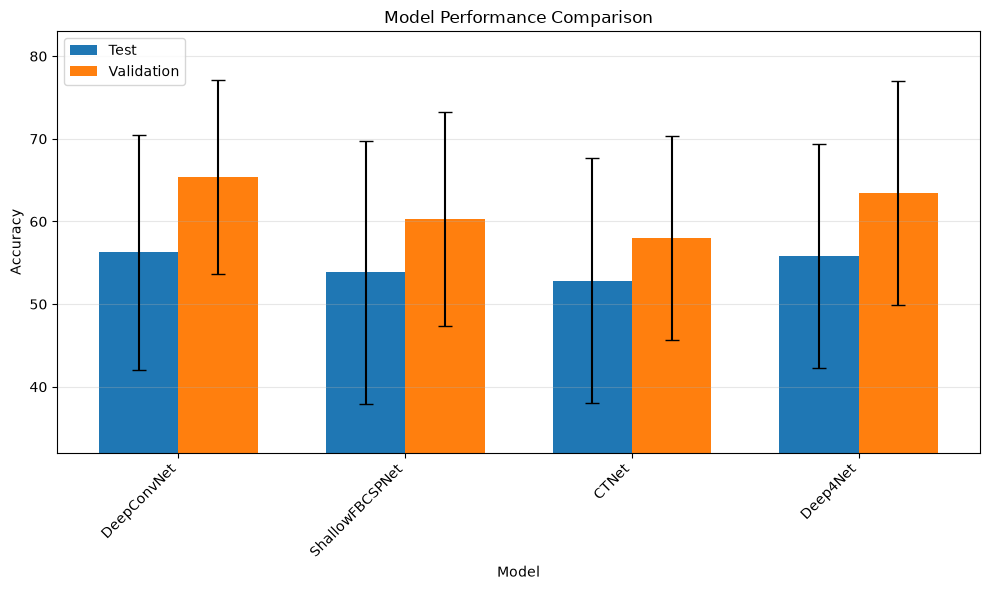

In [18]:
test_mean, test_var, val_mean, val_var = [], [], [], []
epoch_num = 20
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    test_accs, val_accs = [], []
    for subject_id in range(1, 1 + SUBJECT_COUNT):
        train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
        pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_20_RemovedSubject#0.pth')
        model.load_model(pretrained_model_path, verbose=False)
        best_val_accuracy = -float('inf')
        best_epoch = 0
        best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{epoch_num}.pth')
        for epoch in range(epoch_num):
            t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
            val_acc = model.evaluate_accuracy(val_loader)
            if val_acc > best_val_accuracy:
                best_val_accuracy = val_acc
                best_epoch = epoch + 1
                model.save_model(best_model_path, verbose=False)
        
        model.load_model(best_model_path, verbose=False)
        test_acc = model.evaluate_accuracy(test_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        test_accs.append(test_acc)
        val_accs.append(val_acc)
        print(f'Subject #{subject_id}:\tTest Acc: {test_acc:.4f}\tValidation Acc: {val_acc:.4f}')
    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')
visualizer.plot_model_performance(MODEL_ARCHITECTURES, test_mean, test_var, val_mean, val_var)


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
Model loaded successfully from .\Models\Pretrained\EEGNet_0.02_20.pth
Epoch#1 ==== train acc: 58.5366, train loss: 1.4795 ==== val acc: 39.1304, val loss: 1.5978
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 39.1304% (Epoch 1)
Epoch#2 ==== train acc: 66.3957, train loss: 1.2866 ==== val acc: 41.3043, val loss: 1.5389
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 2)
Epoch#3 ==== train acc: 70.7317, train loss: 1.1276 ==== val acc: 43.4783, val loss: 1.4564
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 43.4783% (Epoch 3)
Epoch#4 ==== train acc: 74.5257, train loss: 0.9796 ==== val acc: 47.8261, val loss: 1.4954
Model

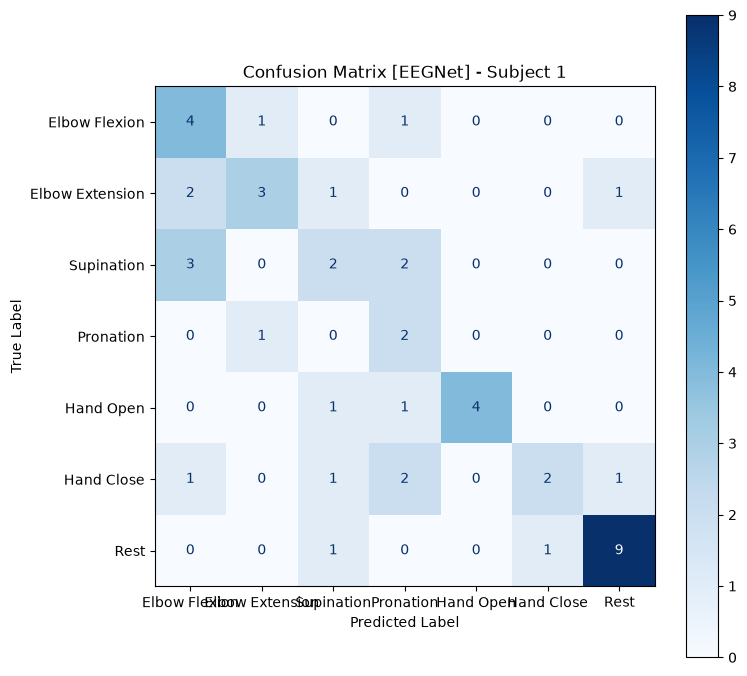

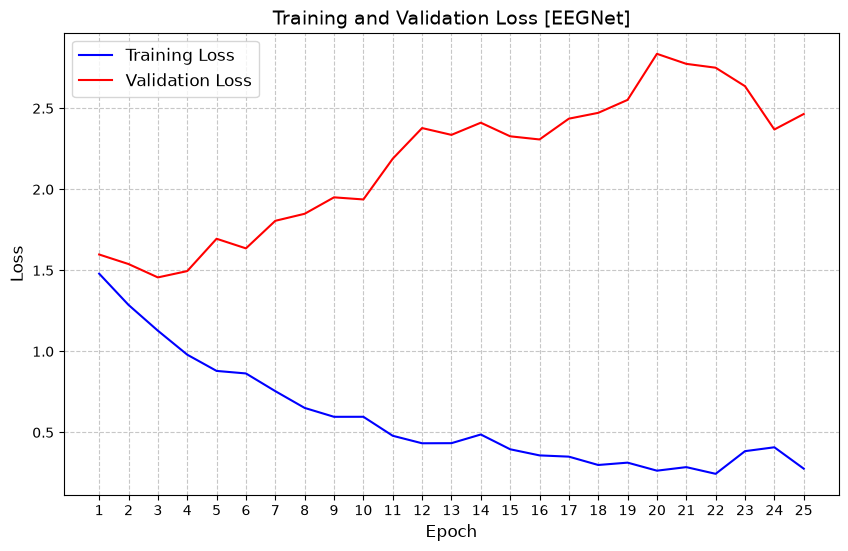

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Pretrained\DeepConvNet_0.02_20.pth
Epoch#1 ==== train acc: 46.6125, train loss: 2.0133 ==== val acc: 36.9565, val loss: 1.5558
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 60.4336, train loss: 1.6281 ==== val acc: 50.0000, val loss: 1.3952
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 50.0000% (Epoch 2)
Epoch#3 ==== train acc: 62.8726, train loss: 1.4632 ==== val acc: 47.8261, val loss: 1.3240
Epoch#4 ==== train acc: 60.7046, train loss: 1.4384 ==== val acc: 39.1304, val loss: 1.6224
Epoch#5 ==== train acc: 65.3117, train loss: 1.3221 ==== val acc: 43.4783, val loss: 1.3448
Epoch#6 ==== train acc: 69.9187, train loss: 1.2272 ==== val acc: 45.6522, val loss: 1.3297
Epoch#7 ==== train acc: 66.6667, train loss: 1.1743 ==== val acc: 

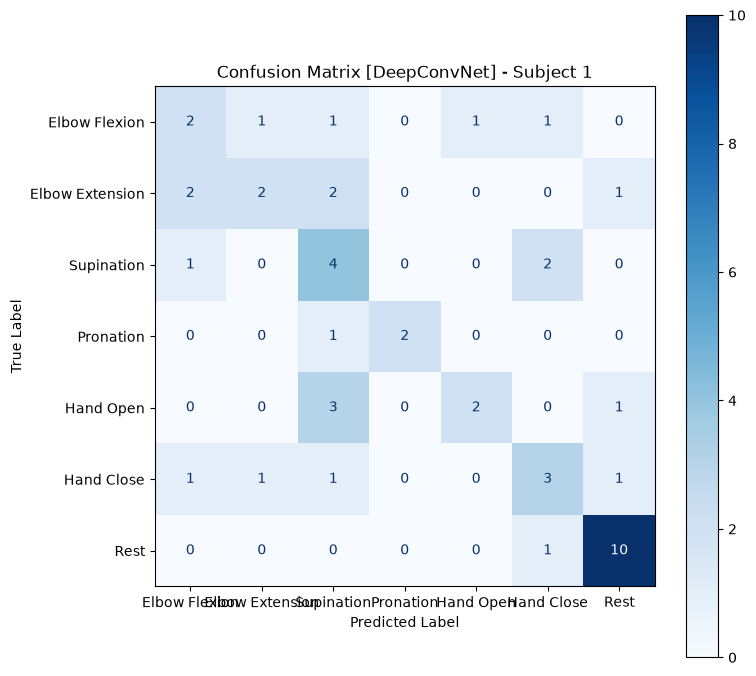

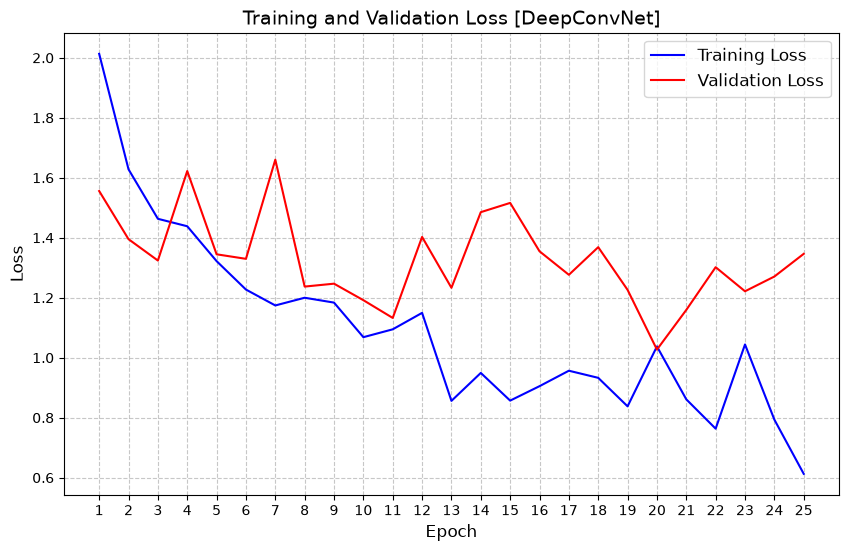

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Pretrained\ShallowFBCSPNet_0.02_20.pth
Epoch#1 ==== train acc: 67.7507, train loss: 1.6376 ==== val acc: 36.9565, val loss: 1.5960
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 73.9837, train loss: 1.3302 ==== val acc: 47.8261, val loss: 1.4361
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 2)
Epoch#3 ==== train acc: 75.8808, train loss: 1.2437 ==== val acc: 45.6522, val loss: 1.5177
Epoch#4 ==== train acc: 77.2358, train loss: 1.0443 ==== val acc: 45.6522, val loss: 1.5878
Epoch#5 ==== train acc: 92.4119, train loss: 0.8092 ==== val acc: 56.5217, val loss: 1.4981
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 56.5217% (Epoch 5)
Ep

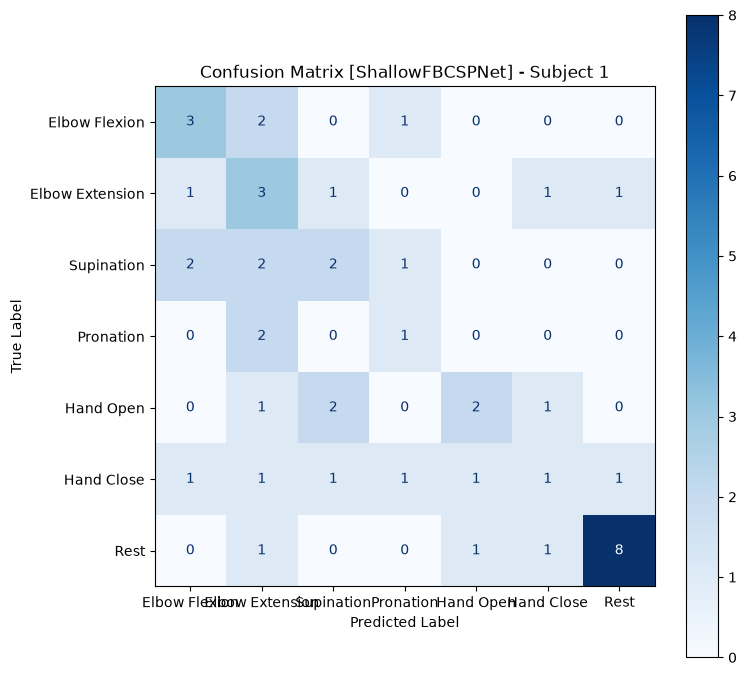

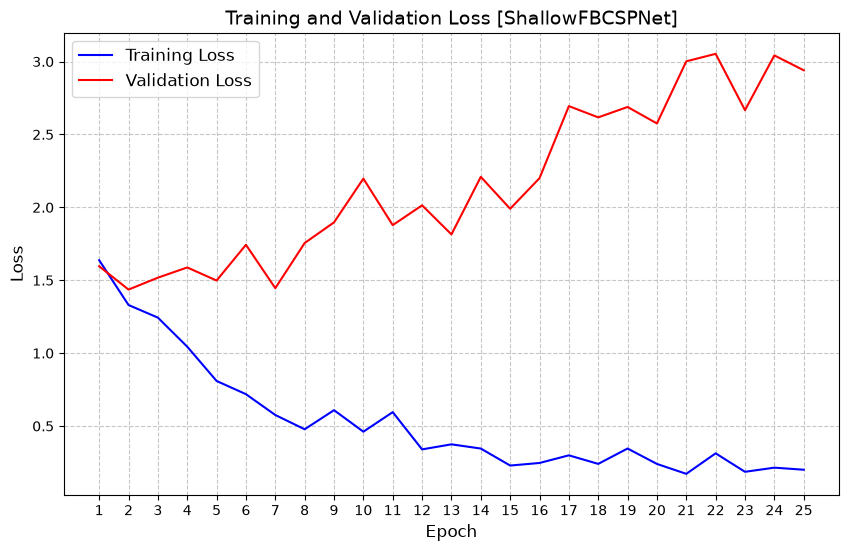

Selected Architecture: EEGNeX
Model loaded successfully from .\Models\Pretrained\EEGNeX_0.02_20.pth
Epoch#1 ==== train acc: 68.0217, train loss: 1.4664 ==== val acc: 36.9565, val loss: 1.5128
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 78.3198, train loss: 1.0548 ==== val acc: 45.6522, val loss: 1.5988
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 2)
Epoch#3 ==== train acc: 83.4688, train loss: 0.8997 ==== val acc: 34.7826, val loss: 1.9982
Epoch#4 ==== train acc: 91.3279, train loss: 0.7523 ==== val acc: 45.6522, val loss: 1.8235
Epoch#5 ==== train acc: 96.2060, train loss: 0.5638 ==== val acc: 45.6522, val loss: 1.9253
Epoch#6 ==== train acc: 95.3930, train loss: 0.5565 ==== val acc: 50.0000, val loss: 1.8290
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best m

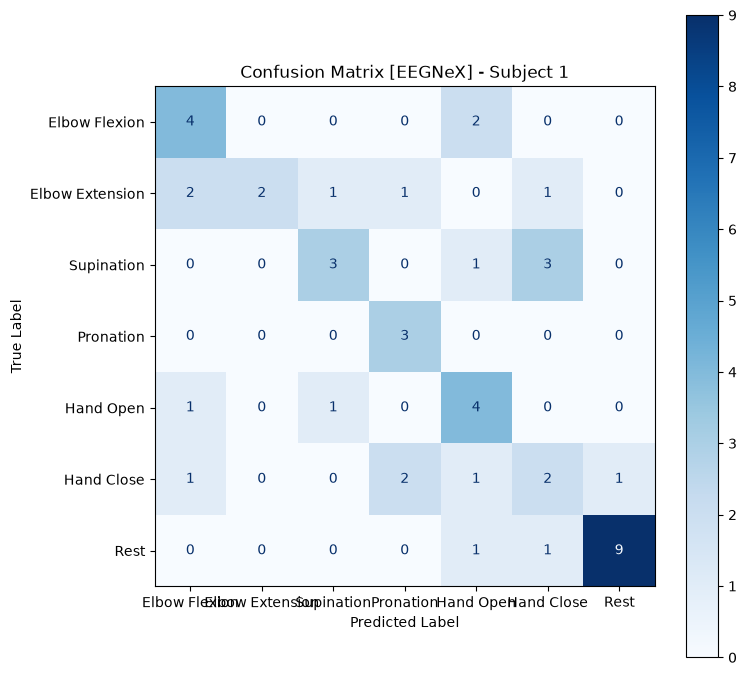

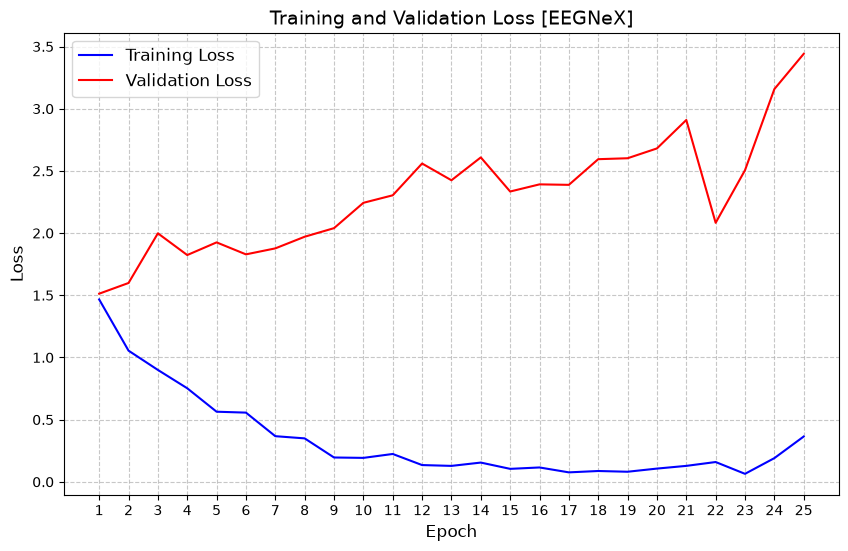

Selected Architecture: CTNet
Model loaded successfully from .\Models\Pretrained\CTNet_0.02_20.pth
Epoch#1 ==== train acc: 81.3008, train loss: 1.1908 ==== val acc: 47.8261, val loss: 1.7504
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 1)
Epoch#2 ==== train acc: 94.5799, train loss: 0.6866 ==== val acc: 47.8261, val loss: 1.6856
Epoch#3 ==== train acc: 96.2060, train loss: 0.4862 ==== val acc: 54.3478, val loss: 1.5479
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 54.3478% (Epoch 3)
Epoch#4 ==== train acc: 97.8320, train loss: 0.3672 ==== val acc: 52.1739, val loss: 1.9114
Epoch#5 ==== train acc: 98.3740, train loss: 0.3119 ==== val acc: 54.3478, val loss: 1.7414
Epoch#6 ==== train acc: 100.0000, train loss: 0.1646 ==== val acc: 56.5217, val loss: 2.0317
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model

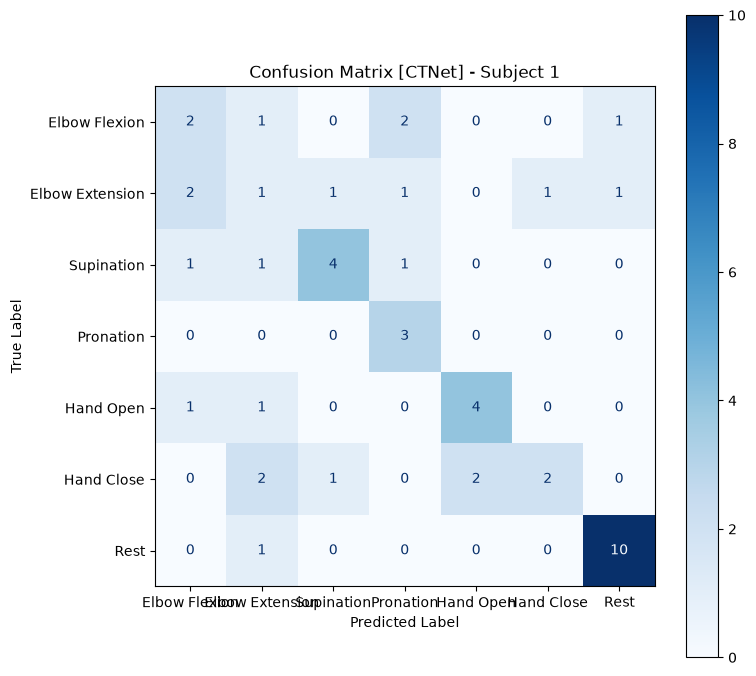

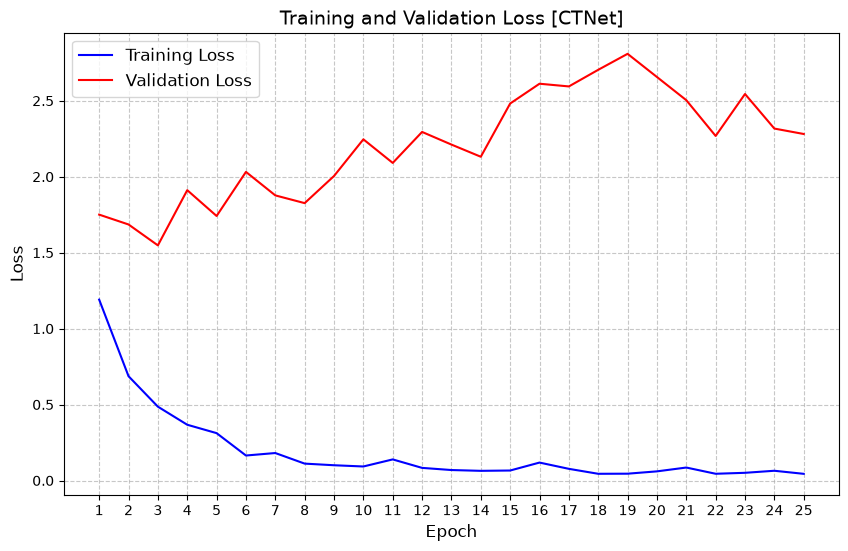

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Pretrained\Deep4Net_0.02_20.pth
Epoch#1 ==== train acc: 53.9295, train loss: 1.6248 ==== val acc: 36.9565, val loss: 1.4942
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 53.1165, train loss: 1.3907 ==== val acc: 41.3043, val loss: 1.4476
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 2)
Epoch#3 ==== train acc: 66.3957, train loss: 1.4400 ==== val acc: 45.6522, val loss: 1.2713
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 3)
Epoch#4 ==== train acc: 63.4146, train loss: 1.2734 ==== val acc: 39.1304, val loss: 1.3072
Epoch#5 ==== train acc: 66.9377, train loss: 1.2956 ==== val acc: 50.0000, val loss: 1.2985
Model saved successfully to .\Models\

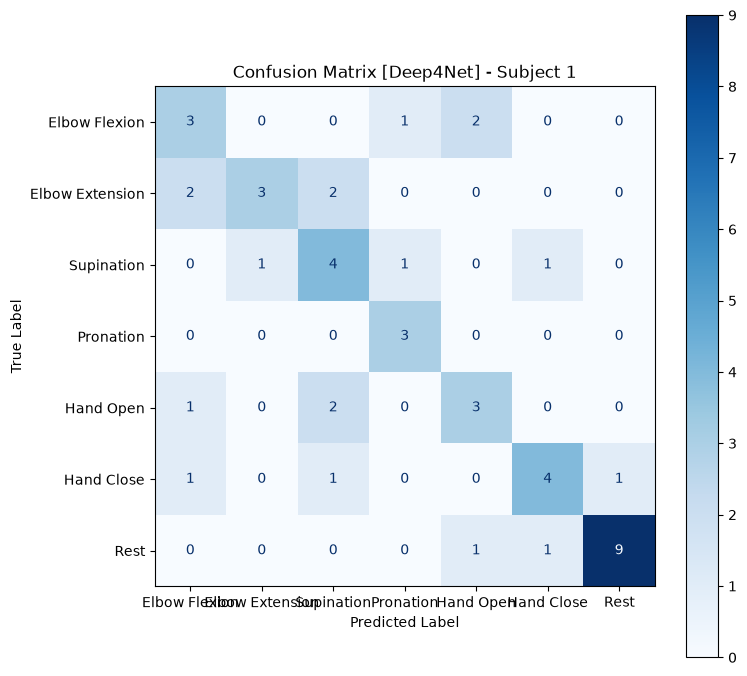

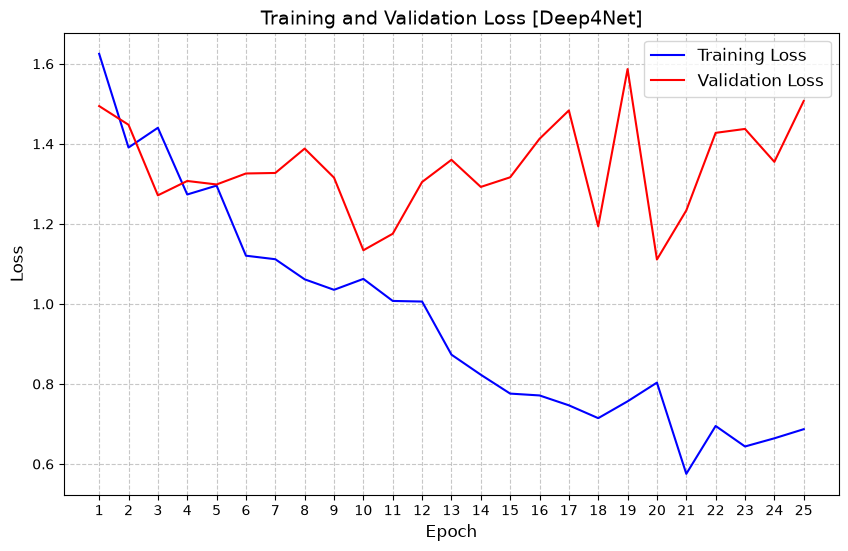

Finished training Subject 1.


In [ ]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')
    model.load_model(pretrained_model_path)
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    visualizer.plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    visualizer.plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")

## Pretraining (14 vs 1)


------ Setting up training for ALL Subjects ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading Sub

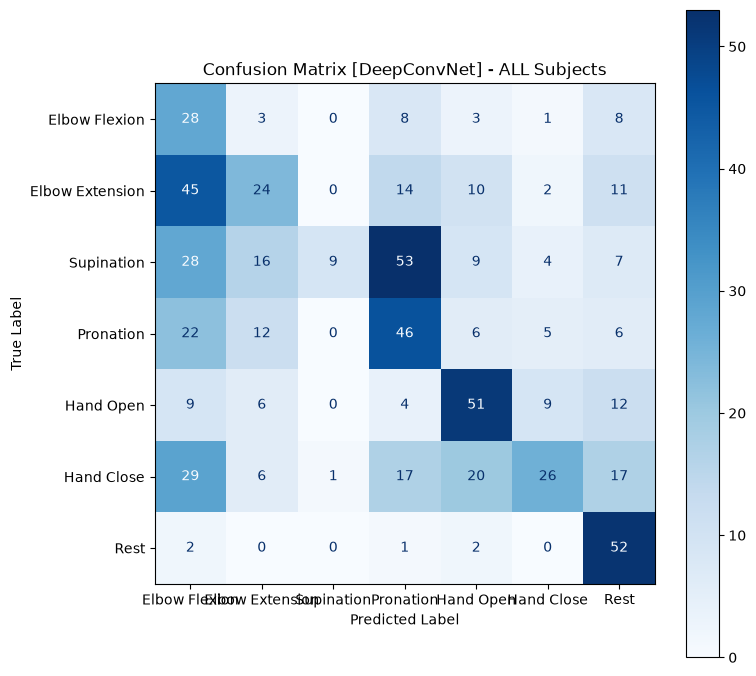

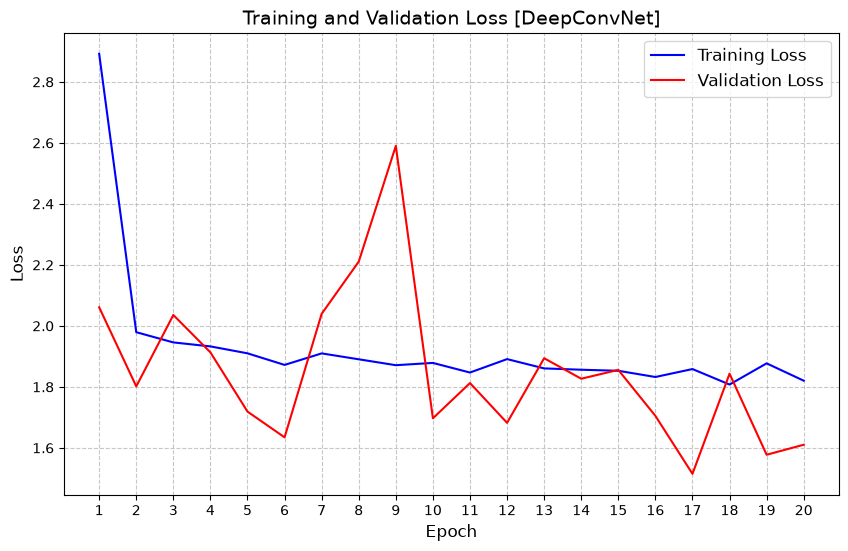

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

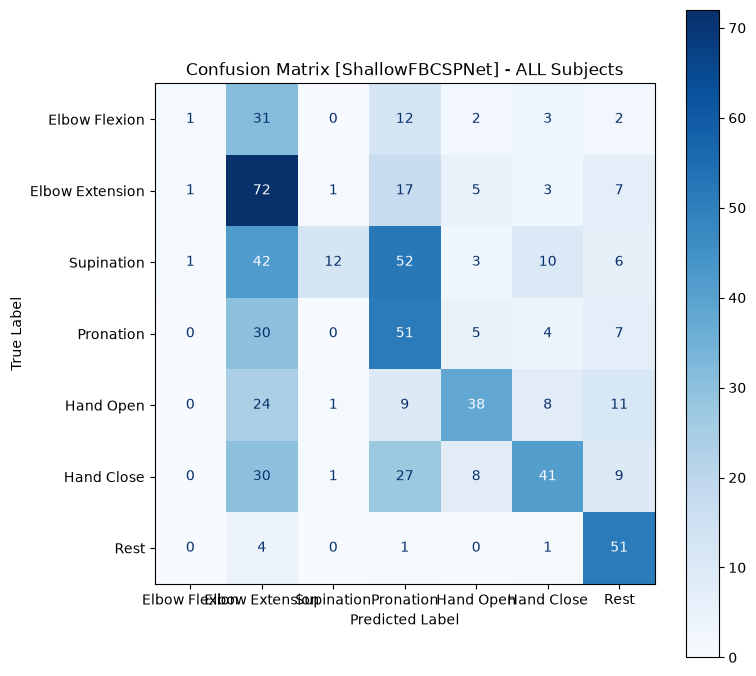

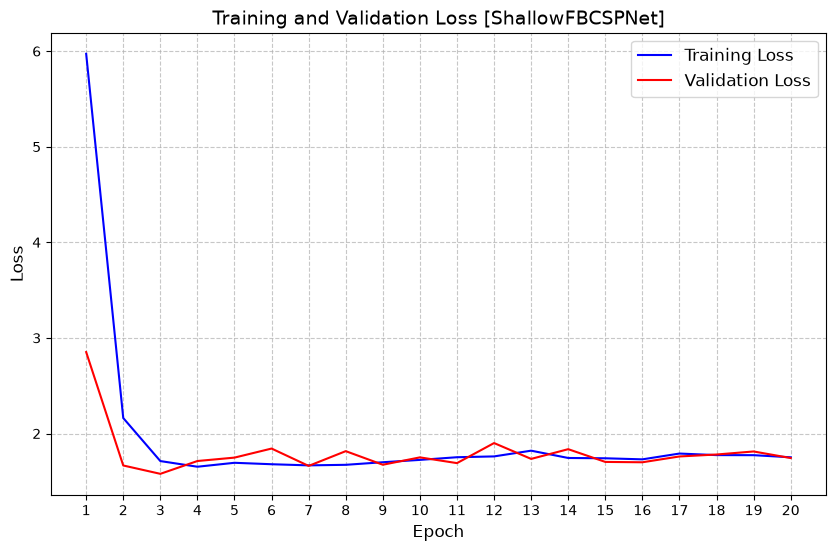

Selected Architecture: CTNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 16, 61, 769]             400
       BatchNorm2d-2          [-1, 16, 61, 769]              32
               ELU-3          [-1, 16, 61, 769]               0
            Conv2d-4           [-1, 32, 1, 769]           1,952
       BatchNorm2d-5           [-1, 32, 1, 769]              64
               ELU-6           [-1, 32, 1, 769]               0
         AvgPool2d-7           [-1, 32, 1, 192]               0
           Dropout-8           [-1, 32, 1, 192]               0
            Conv2d-9           [-1, 32, 1, 192]          15,360
      BatchNorm2d-10           [-1, 32, 1, 192]              64
              ELU-11           [-1, 32, 1, 192]               0
           Conv2d-12           [-1, 32, 1, 192]             480
      BatchNorm2d-13           [-1, 32, 1, 192]              64
          

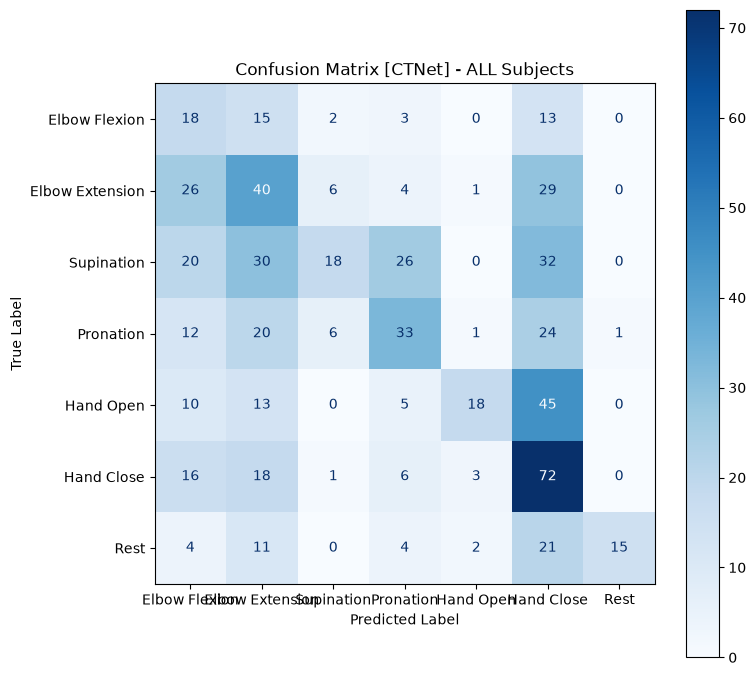

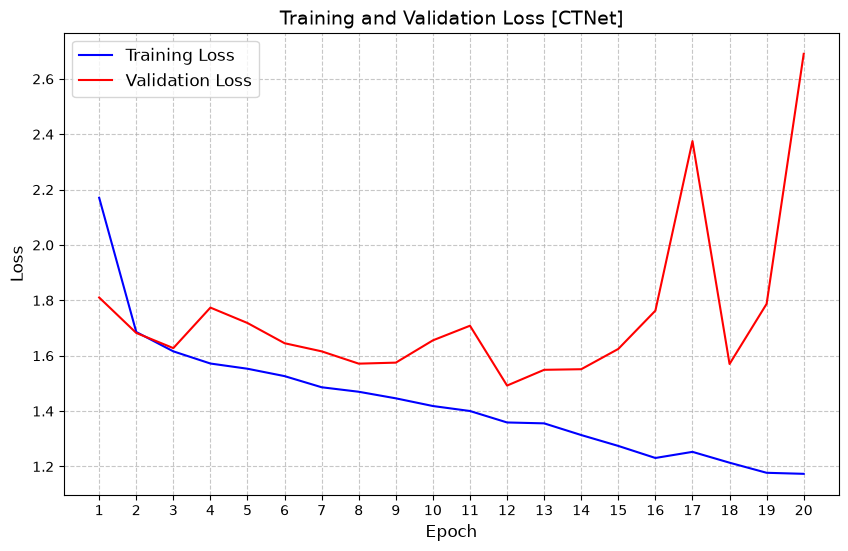

Selected Architecture: Deep4Net
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
       

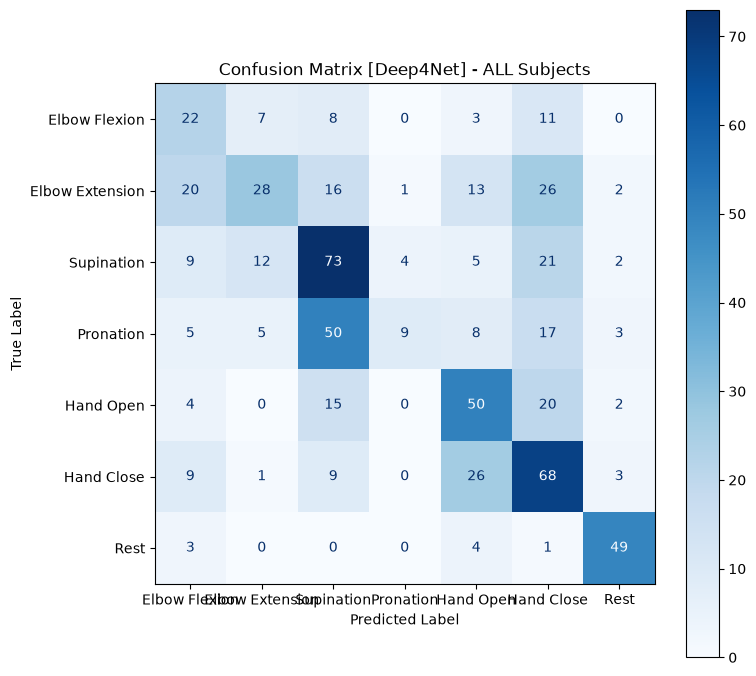

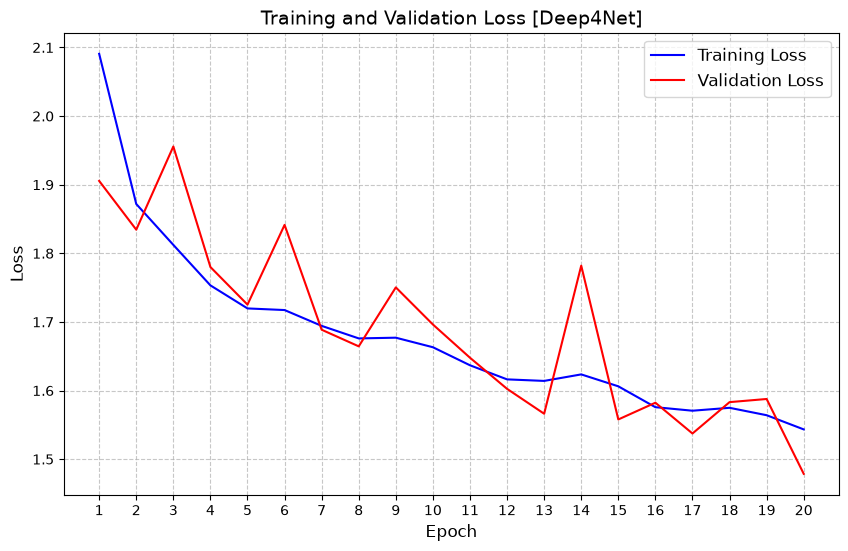

Finished training.


In [6]:
print(f"\n------ Setting up training for ALL Subjects ------")
subjects=[i + 1 for i in range(SUBJECT_COUNT-1)]
full_train_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED)
full_val_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED, train=False)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=P_LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}_14s.pth')

    for epoch in range(P_EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(full_train_loader, full_val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(full_train_loader)
        val_acc = model.evaluate_accuracy(full_val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

    model.save_model(model_path)

    print('\nModel Final Accuracy:')
    print('\tTrain:', model.evaluate_accuracy(full_train_loader))
    print('\tValidation:', model.evaluate_accuracy(full_val_loader))

    visualizer.plot_confusion_matrix(
        model=model,
        data_loader=full_val_loader,
        class_names=classes,
        title=f'Confusion Matrix [{architecture}] - ALL Subjects'
    )
    visualizer.plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training.")

## Fine-tunning (14 vs 1)

#################### Selected Architecture: DeepConvNet ####################
Loading Subject 15 from cache...
Normalizing data based on training set statistics...
Subject #15:	Test Acc: 51.0638	Validation Acc: 52.1739
Results for Model Accuracy
Validation: ~N(51.064, 0.000), Test: ~N(52.174, 0.000)

#################### Selected Architecture: ShallowFBCSPNet ####################
Loading Subject 15 from cache...
Normalizing data based on training set statistics...
Subject #15:	Test Acc: 51.0638	Validation Acc: 47.8261
Results for Model Accuracy
Validation: ~N(51.064, 0.000), Test: ~N(47.826, 0.000)

#################### Selected Architecture: CTNet ####################
Loading Subject 15 from cache...
Normalizing data based on training set statistics...
Subject #15:	Test Acc: 44.6809	Validation Acc: 45.6522
Results for Model Accuracy
Validation: ~N(44.681, 0.000), Test: ~N(45.652, 0.000)

#################### Selected Architecture: Deep4Net ####################
Loading Subject 15 from c

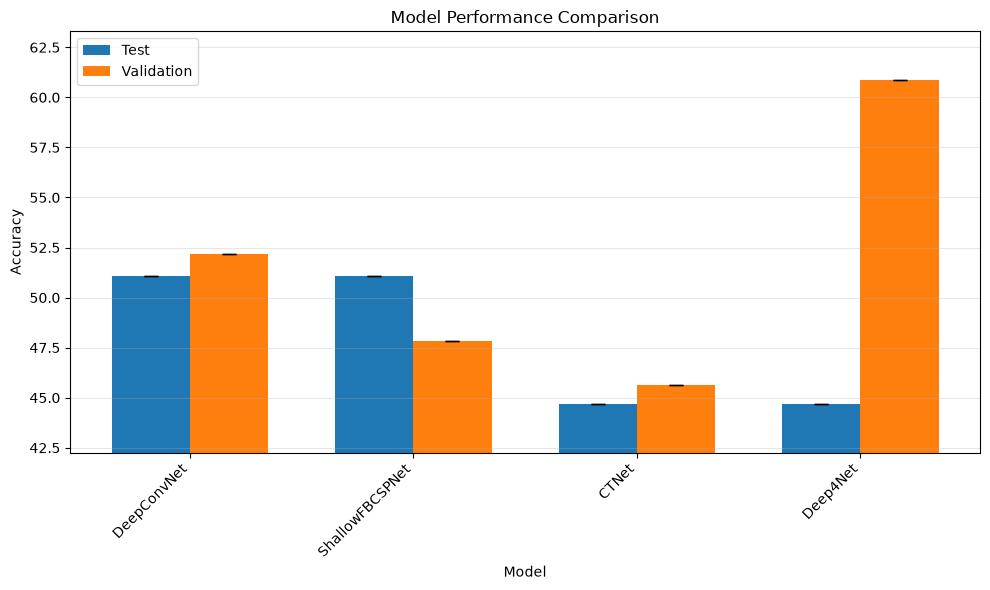

In [7]:
subject_id = 15
test_mean, test_var, val_mean, val_var = [], [], [], []
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    test_accs, val_accs = [], []
    train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
    pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}_14s.pth')
    model.load_model(pretrained_model_path, verbose=False)
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}_14s.pth')
    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path, verbose=False)
    
    model.load_model(best_model_path, verbose=False)
    test_acc = model.evaluate_accuracy(test_loader)
    val_acc = model.evaluate_accuracy(val_loader)
    test_accs.append(test_acc)
    val_accs.append(val_acc)
    print(f'Subject #{subject_id}:\tTest Acc: {test_acc:.4f}\tValidation Acc: {val_acc:.4f}')
    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')
visualizer.plot_model_performance(MODEL_ARCHITECTURES, test_mean, test_var, val_mean, val_var)